<a href="https://colab.research.google.com/github/RajeshRanaGiet/AML-LAB/blob/main/Experiment%203/exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
def regression_model(X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    intercept = model.intercept_
    coefficients = model.coef_
    equation = f"y = {intercept:.4f}"
    for coef, col in zip(coefficients, X.columns):
        equation += f" + {coef:.4f}*{col}"
    print(f"\n{'='*60}")
    print(title)
    print("="*60)
    print(equation)
    print(f"Mean Squared Error : {mse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    return model, X_test, y_test, predictions, mse, mae, rmse, r2

Dataset Shape:
(379, 5)

First Five Rows:
   SEM 1  SEM 2  SEM 3  SEM 4  SEM 5
0   6.60   7.60   6.90   7.22   7.08
1   7.77   7.22   7.00   7.90   7.47
2   6.90   6.00   7.12   7.54   6.89
3   5.50   6.60   6.70   6.50   6.33
4   7.20   6.00   7.21   7.70   7.03

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEM 1   379 non-null    float64
 1   SEM 2   379 non-null    float64
 2   SEM 3   379 non-null    float64
 3   SEM 4   379 non-null    float64
 4   SEM 5   379 non-null    float64
dtypes: float64(5)
memory usage: 14.9 KB
None

Missing Values:
SEM 1    0
SEM 2    0
SEM 3    0
SEM 4    0
SEM 5    0
dtype: int64

Statistical Summary:
            SEM 1       SEM 2       SEM 3       SEM 4       SEM 5
count  379.000000  379.000000  379.000000  379.000000  379.000000
mean     5.908707    6.015858    6.103852    6.167546    6.050765


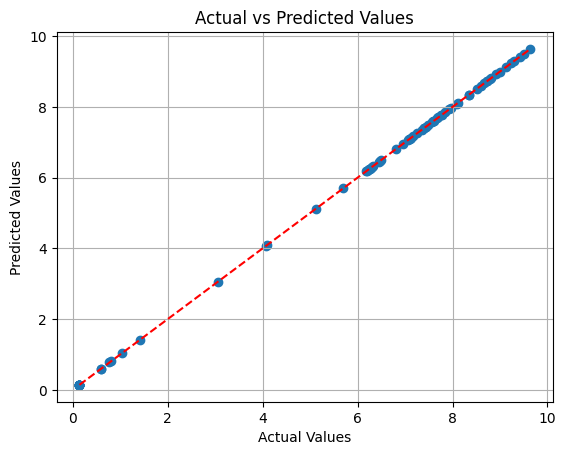

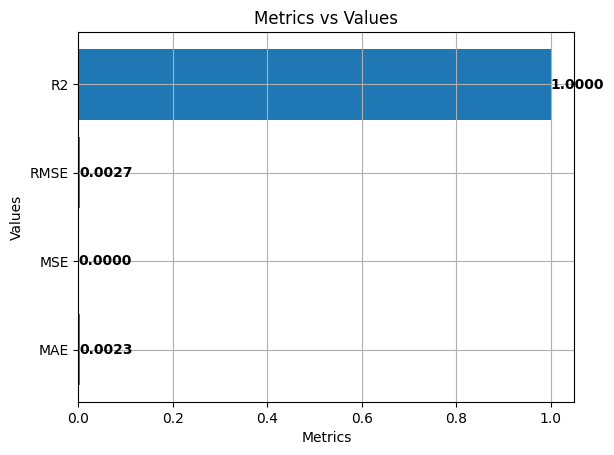

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

data = pd.read_csv('https://raw.githubusercontent.com/RajeshRanaGiet/AML-LAB/main/Experiment%203/studentGradeDataSet.csv')

print("Dataset Shape:")
print(data.shape)

print("\nFirst Five Rows:")
print(data.head())

print("\nDataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nStatistical Summary:")
print(data.describe())

x = data.drop('SEM 5', axis=1)
y = data['SEM 5']

model, X_test, y_test, predictions, mse, mae, rmse, r2 = regression_model(x, y, "Multiple Linear Regression")

pred_model = model.predict(X_test)

print("Enter the data for prediction :- ")
s1 = int(input("Enter the 1st Semester marks: "))
s2 = int(input("Enter the 2nd Semester marks: "))
s3 = int(input("Enter the 3rd Semester marks: "))
s4 = int(input("Enter the 4th Semester marks: "))
test = pd.DataFrame({"SEM 1" : [s1],
                     "SEM 2" : [s2],
                     "SEM 3" : [s3],
                     "SEM 4" : [s4]})

pred_val = model.predict(test)
print("The predicted 5th sem mark is : ", pred_val[0])

plt.scatter(y_test, pred_model)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.grid(True)
plt.show()

metrics = ["MAE", "MSE", "RMSE", "R2"]
values = [mae, mse, rmse, r2]

bars = plt.barh(metrics, values)
for bar in bars:
  width = bar.get_width()
  plt.annotate(f"{width:.4f}", xy=(width, bar.get_y() + bar.get_height() / 2),ha="left", va="center", fontweight="bold")
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.title("Metrics vs Values")
plt.grid(True)
plt.show()



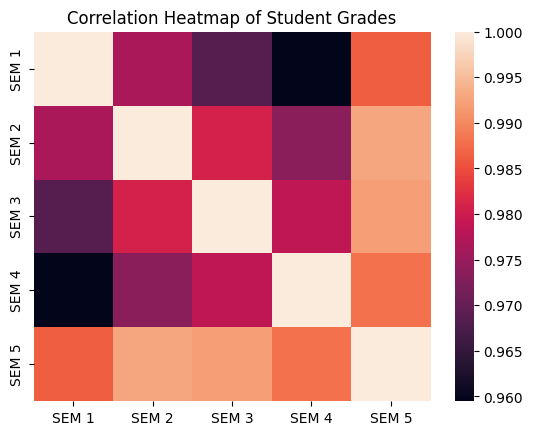

In [4]:
#heat map
sns.heatmap(data.corr())
plt.title('Correlation Heatmap of Student Grades')
plt.show()

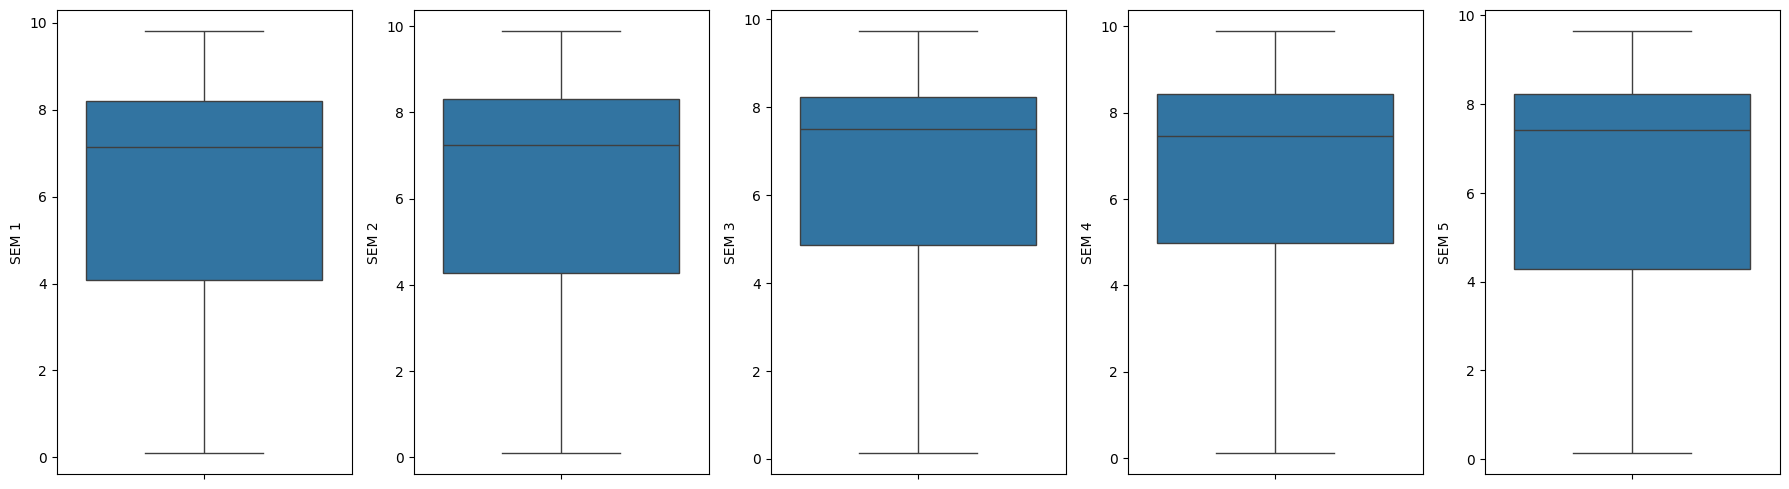

In [5]:
fig, axes = plt.subplots(1, len(data.columns), figsize=(18,5))
for i,col in enumerate(data.columns):
    sns.boxplot(y=data[col], ax=axes[i])
plt.tight_layout()
plt.show()


--- Simple Linear Regression for SEM 1 ---

Multiple Linear Regression
y = 0.3370 + 0.9661*SEM 1
Mean Squared Error : 0.1802
Mean Absolute Error: 0.3519
Root Mean Squared Error: 0.4245
R² Score: 0.9827


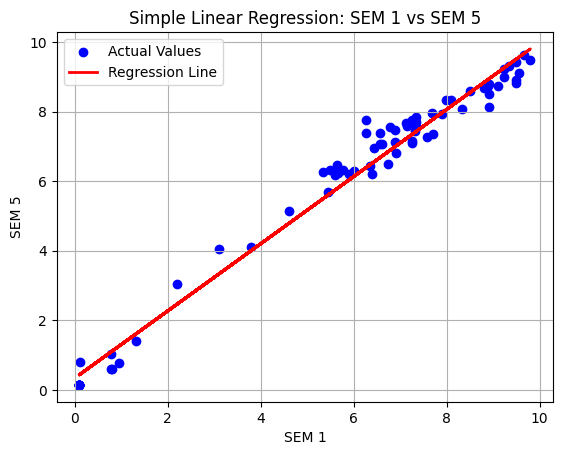


--- Simple Linear Regression for SEM 2 ---

Multiple Linear Regression
y = 0.1694 + 0.9786*SEM 2
Mean Squared Error : 0.1175
Mean Absolute Error: 0.2454
Root Mean Squared Error: 0.3428
R² Score: 0.9887


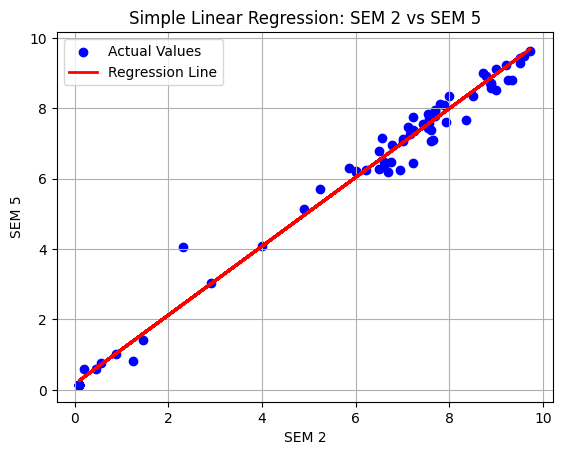


--- Simple Linear Regression for SEM 3 ---

Multiple Linear Regression
y = 0.0032 + 0.9901*SEM 3
Mean Squared Error : 0.1285
Mean Absolute Error: 0.2618
Root Mean Squared Error: 0.3585
R² Score: 0.9876


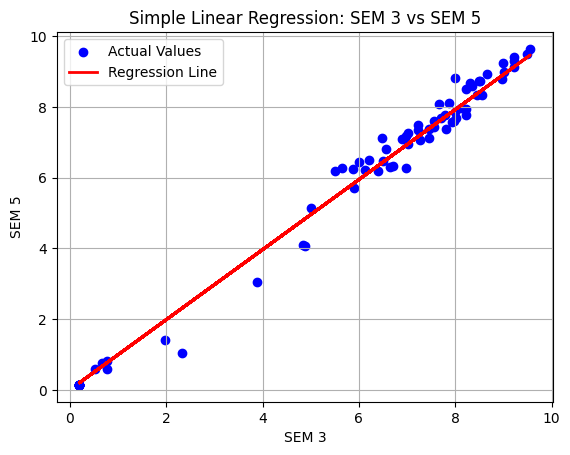


--- Simple Linear Regression for SEM 4 ---

Multiple Linear Regression
y = 0.0326 + 0.9774*SEM 4
Mean Squared Error : 0.2284
Mean Absolute Error: 0.3557
Root Mean Squared Error: 0.4779
R² Score: 0.9780


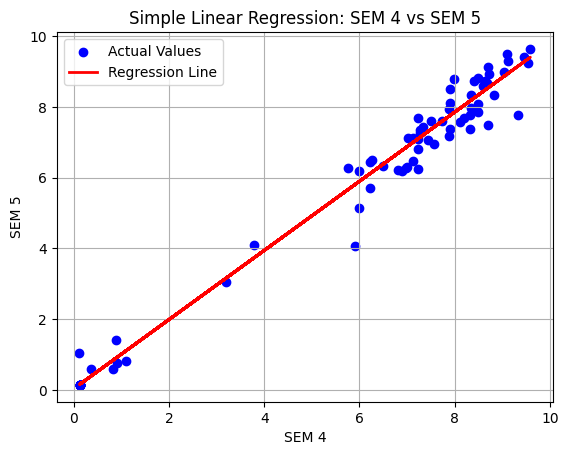

In [7]:
for feature in x.columns:
    print(f"\n--- Simple Linear Regression for {feature} ---")
    x_simple = data[[feature]]
    y_simple = data['SEM 5']

    model, X_test_simple, y_test_simple, predictions_simple, mse, mae, rmse, r2 = regression_model(x_simple, y_simple, "Multiple Linear Regression")

    plt.scatter(X_test_simple, y_test_simple, color='blue', label='Actual Values')
    plt.plot(X_test_simple, predictions_simple, color='red', linewidth=2, label='Regression Line')
    plt.xlabel(feature)
    plt.ylabel('SEM 5')
    plt.title(f'Simple Linear Regression: {feature} vs SEM 5')
    plt.legend()
    plt.grid(True)
    plt.show()